In [1]:
import os
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from tqdm import tqdm
from numpy import sin, pi
%matplotlib widget

In [2]:
start = dt.datetime(2000,1,9); 
stop = dt.datetime(2000,1,13);

## Solar wind and SuperMAG data

In [3]:
## ACE data files from Purbi's code
os.chdir("C:/Users/soumy/OneDrive/Documents/src/2024-04 WINDMI Identification/data1/")
data = pd.read_csv("ACE_" + str(start.year) + ".csv")
data.index = pd.to_datetime(data.Time)
data.drop(columns=["Time"], inplace=True)
data = data.iloc[(data.index >= start-dt.timedelta(hours=2)) & (data.index <= stop + dt.timedelta(hours=2))]

In [4]:
SuperMag_filename = os.path.join("../Data0", f"SuperMag_{start.year}.csv")
SuperMag = pd.read_csv(SuperMag_filename)
SuperMag.index = pd.to_datetime(SuperMag.Date_UTC)
SuperMag.drop(columns=["Date_UTC"], inplace=True)

## Calculate the time delay

In [5]:
# time_substorm = np.arange(200, 600, 1)  # time indices for substorm interval
Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
R_subsolar = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
t_delay = -((250.0 - np.nanmean(R_subsolar)) * 6380.0) / np.nanmean(data['Vx'])  # for constant delay
t_delay_windmi = -((250.0 - R_subsolar) * 6380.0) / data['Vx'].rolling(window=20, min_periods=1, center=True).mean()  # time delay array for WINDMI model


## Shift the ACE Data

In [6]:
def apply_windmi_time_shift(data, t_delay_windmi):
    data_shifted = data.copy()
    # Shift time index by time-varying delay (seconds)
    data_shifted.index = data_shifted.index + pd.to_timedelta(
        t_delay_windmi, unit="s")
    data_shifted = data_shifted.sort_index()
    data_shifted = data_shifted[~data_shifted.index.isna()]
    #remove duplicate indices after shifting
    data_shifted = data_shifted[~data_shifted.index.duplicated(keep='first')]

    t_start = data_shifted.index.min().floor("min")
    t_end   = data_shifted.index.max().ceil("min")
    x0 = np.array((data_shifted.index - t_start)/dt.timedelta(seconds=1))  # original time index in seconds
    x1_time = pd.date_range(t_start, t_end, freq="1min")      # <- whole minutes
    x1 = np.array((x1_time - t_start)/dt.timedelta(seconds=1))  # resampled time index in seconds 
    df = pd.DataFrame(index=x1_time)
    for col in data_shifted.columns:
        y0 = data_shifted[col].values
        y1 = interp1d(x0, y0, kind="linear", bounds_error=False, fill_value=np.nan)(x1)
        df[col] = y1
    #remove rows with NaN values
    
    df = df.dropna().reset_index()
    df = df.set_index('index')
    return df

data = apply_windmi_time_shift(data, t_delay_windmi)
data = data.loc[start:stop];

## Calculate the input voltage

In [7]:
Bx = data['Bx']; By = data['By']; Bz = data['Bz']; # IMF components in nT
Vx = data['Vx']; Vy = data['Vy']; Vz = data['Vz']; # Solar wind velocity components in km/s
Np = data['Np']; # Solar wind proton density in cm^-3 

In [8]:
# Input voltages
R_E = 6380.0e3  # Earth radius in m
Ly = 10.0 * R_E # effective width of magnetosphere in solar wind dynamo

# VBs formula
Bz_input = 0.5 * (np.abs(Bz) - Bz)  # if Bz < 0, Bz_input = |Bz| else Bz_input = 0
Vsw0 = 4000.0 + (1.0e-6 * Ly * np.abs(Vx * Bz_input))  # Solar wind coupling function

# Siscoe-Hill formula
m_p = 1.67e-27  # mass of proton in kg
B_abs = np.abs(Bx**2 + By**2 + Bz**2) # magnitude of IMF in nT
theta = np.arccos(Bz/B_abs)  # IMF clock angle in radians
v_sw = np.sqrt(Vx**2 + Vy**2 + Vz**2)  # solar wind speed in km/s
Esw = (v_sw*1e3) * (np.sqrt(By**2 + Bz**2)*1e-9) * np.sin(theta/2.0);
Psw = m_p * (Np * 1.0e6) * ((v_sw*1.0e3)**2)  # solar wind dynamic pressure in Pa
Phi_M = 30.0 + (57.6 * (Esw*1.0e3) * ((1.0e9 * Psw) ** (-1.0 / 6.0))) # magnetospheric potential in kV
Vsw1 = 1e3*Phi_M;

C0 = 0.77;
F107 = 172.42; # its supposed to be monthly mean
SigmaP = C0 * np.sqrt(F107);
Phi_S = 1600.0 * ((Psw*1.0e9)**(1/3))/SigmaP # saturation voltage
Phi_H = (Phi_M * Phi_S) / (Phi_M + Phi_S)  # Hill potential

# Newell et al. 2007
DPhi_mp = (np.abs(Vx)**(4/3)) * (B_abs**(2/3)) * (np.sin(theta / 2.0)**(8/3))  # dayside reconnection rate in kV
Vsw2 = 4000.0 + (np.mean(Vsw0)/np.mean(DPhi_mp))*DPhi_mp;  # scaled Newell coupling function

data['vBs'] = Vsw0;  # choose VBs as input voltage for WINDMI model

# Substorm lists

In [9]:
# Get the substorm lists
keywords = ['Forsyth', 'Frey','Liou','Newell','Ohtani']

for key in keywords:
    filename = f"C:/Users/soumy/OneDrive/Documents/src/2024-04 WINDMI Identification/Data0/Substorms_{key}_1970_to_2022.csv"
    df = pd.read_csv(filename)
    df.index = pd.to_datetime(df['Date_UTC'])
    globals()[f"{key}"] = df.loc[start:stop]

# WINDMI code

In [10]:
# create a dictionary of inputs
p = {
    # --- Inductances ---
    "L": 90.0,                    # Inductance of the lobe cavity
    "L1": 20.0,                    # Region-1 current inductance
    "L2": 8.0,                     # Ring current inductance

    "L_y": 3.2e7,                  # Cross-tail length scale [m]

    # --- Capacitances ---
    "C": 5.0e4,                   # Plasma sheet capacitance
    "C1": 8.0e2,                   # capacitance of R1 current loop

    # --- Resistances ---
    "R_prc": 0.1,                  # Partial ring current resistance
    "R_A2": 0.3,                   # Region-2 Alfven resistance

    "M": 0.1,                      # mutual inductance between I and I1 (in the paper its 1.0?)

    # --- Currents ---
    "DeltaI": 1.25e5,              # Delta I in theta function

    # --- Conductances ---
    "Sigma": 8.0,                  # Plasma sheet conductance
    "SigmaI": 3.0,                 # pedersen conductance of westward electrojet current

    # --- Magnetic / EM constants ---
    "u0": 4.2e-9,                 # heat flux limit paramter
    "Aeff": 8.14e13,              # Effective cross-sectional area [m^2]
    "Btr": 5.0e-9,                # Trigger magnetic field threshold [T]

    # --- Energetics ---
    "Omega_cps": 2.6e24,           # Plasma sheet volume
    "Alpha": 8.0e11,               # Energy coupling coefficient

    # --- Time constants ---
    "tauE": 30.0 * 60.0,          # Energy decay timescale [s]
    "tauk": 10.0 * 60.0,          # confinement time of parallel flow [s]
    "taurc": 12.0 * 3600.0,       # Ring current decay time [s]
            
    "beta_sw": 0.7,               # Coupling factor for SW across magnetopause

    "Ic_trig": 2.0e7              # Threshold current for substorm onset in A    
}

In [11]:
def _H_switch(I, Ic, DeltaI):
    # Eq. (17): H(I - Ic) = 0.5 * (1 + tanh((I - Ic)/DeltaI))
    return 0.5 * (1.0 + np.tanh((I - Ic) / DeltaI))

def windmi_rhs(t, p, x, Vsw):
    """
    State vector (paper): X(t) = (I, V, I1, VI, p, Kk, I2, Wrc)
    Eqs. (9)-(16) in Spencer & Horton (2006). :contentReference[oaicite:2]{index=2}
    """

    I, V, I1, VI, pres, Kk, I2, Wrc = x
    ## WINDMI constants and parameters
    L = p["L"] ;L1 = p["L1"]; L2 = p["L2"] ; L_y = p["L_y"];                  
    C = p["C"]; C1 = p["C1"];
    R_prc = p["R_prc"]; R_A2 = p["R_A2"];

    M = p["M"]; DeltaI = p["DeltaI"]; SigmaI = p["SigmaI"];
    u0 = p["u0"]; Aeff = p["Aeff"]; Btr = p["Btr"];
    
    Omega_cps = p["Omega_cps"]; Alpha = p["Alpha"];
    tauE = p["tauE"]; tauk = p["tauk"]; taurc = p["taurc"]; beta_sw = p["beta_sw"];

    # The real players 
    L = p["L"]; C = p["C"]; Sigma = p["Sigma"]; Ic_trig = p["Ic_trig"];

    # --- derived terms ---
    H = _H_switch(I, Ic_trig, DeltaI)

    # --- failsafe for non-physical negative values ---
    pres = max(pres, 0.0);
    Kk   = max(Kk,   0.0);
    Wrc  = max(Wrc,  0.0);

    Ips = Alpha * np.sqrt(max(pres, 0.0))  # Ips = a p^{1/2}

    # Unloading / injection coupling term used in Eq. (11) and Eq. (16)
    # (paper term appears as p V Aeff / (Xcps Btr Ly) in Eq. 11 and p V Aeff / (Btr Ly) in Eq. 16)
    inj_ps = (pres * V * Aeff) / (Omega_cps * Btr * L_y)
    inj_rc = (pres * V * Aeff) / (Btr * L_y)

    # --- Solve the coupled inductive pair (Eqs. 9 & 13) for dI/dt and dI1/dt ---
    # Eq (9):  L dI/dt  = bsw Vsw - V + M dI1/dt
    # Eq (13): LI dI1/dt = V - VI + M dI/dt
    # Write as:
    # [ L   -M ] [dI ] = [ bsw Vsw - V ]
    # [ -M  LI ] [dI1]   [ V - VI       ]
    A = np.array([[L, -M],
                [-M, L1]], dtype=float)
    b = np.array([beta_sw*Vsw - V,
                V - VI], dtype=float)

    detA = A[0,0]*A[1,1] - A[0,1]*A[1,0]   # = L*L1 - M^2

    # failsafe thresholds (tune if needed)
    eps_det = 1e-12
    max_cond = 1e12

    if abs(detA) < eps_det or np.linalg.cond(A) > max_cond:
        # fallback: least-squares / pseudo-inverse (won’t crash)
        dI, dI1 = np.linalg.lstsq(A, b, rcond=None)[0]
    else:
        dI, dI1 = np.linalg.solve(A, b)

    # Eq (10): C dV/dt = I - I1 - Ips - R V
    dV = (I - I1 - Ips - Sigma*V) / C

    # Eq (11): (3/2) dp/dt = R V^2 / Xcps - u0 p Kk^{1/2} H - p V Aeff/(Xcps Btr Ly) - (3p)/(2 tauE)
    # => dp/dt = (2/3)*[ ... ]
    dP = (2.0/3.0) * ( ((Sigma * V * V) / Omega_cps)
                       - (u0 * pres * np.sqrt(max(Kk, 0.0)) * H)
                       - inj_ps
                       - ((3.0 * pres)/(2.0 * tauE)) )

    # Eq (12): dKk/dt = Ips V - Kk/tauk
    dKk = Ips * V - (Kk / tauk)

    # Eq (14): CI dVI/dt = I1 - I2 - RI VI
    dVI = (I1 - I2 - (SigmaI * VI)) / C1

    # Eq (15): L2 dI2/dt = VI - (Rprc + RA2) I2
    dI2 = (VI - ((R_prc + R_A2) * I2)) / L2

    # Eq (16): dWrc/dt = Rprc I2^2 + p V Aeff/(Btr Ly) - Wrc/taurc
    dWrc = (R_prc * (I2**2)) + inj_rc - (max(Wrc, 0.0) / taurc)

    return np.array([dI, dV, dI1, dVI, dP, dKk, dI2, dWrc], dtype=float)

def solve_windmi_rk45(t_seconds,
                      p,
                      Vsw,
                      x0=None, 
                      rtol=1e-6, 
                      atol=1e-9,  
                      Ic_trig=None,
                      L = None, C = None, Sigma = None):
    
    t_seconds = np.asarray(t_seconds, dtype=float);
    Vsw = np.asarray(Vsw, dtype=float);
    # default initial condition if not provided
    if x0 is None:
        x0 = np.zeros(8, dtype=float)
    else:
        x0 = np.asarray(x0, dtype=float)
        if x0.shape != (8,):
            raise ValueError("x0 must be shape (8,) = [I, V, I1, VI, p, Kk, I2, Wrc]")
    Vsw_of_t = interp1d(
        t_seconds, Vsw,
        kind="linear",
        bounds_error=False,
        fill_value=(Vsw[0], Vsw[-1])
    )
    p.update({
    k: v for k, v in {
        "Ic_trig": Ic_trig,
        "L": L,
        "C": C,
        "Sigma": Sigma
    }.items() if v is not None
})
    def rhs(t, x):
        return windmi_rhs(t, p, x, Vsw_of_t(t))
    sol = solve_ivp(rhs, 
                    (t_seconds[0], t_seconds[-1]), 
                    y0=x0, 
                    t_eval=t_seconds, 
                    rtol=rtol, 
                    atol=atol,
                    max_step=60.0)
    if not sol.success:
        k = -1 if sol.t.size > 0 else None
        if k is not None:
            print("FAIL t =", sol.t[k])
            print("STATE @ fail:", sol.y[:, k])
        print("MESSAGE:", sol.message)
        raise RuntimeError(sol.message)
    return {
        "t": sol.t,
        "I":   sol.y[0],
        "V":   sol.y[1],
        "I1":  sol.y[2],
        "VI":  sol.y[3],
        "pres":   sol.y[4],
        "Kk":  sol.y[5],
        "I2":  sol.y[6],
        "Wrc": sol.y[7]}, p


# Case 1: Constant L,C,sigma + daily Ic

In [12]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p0 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p0, 
                        data['vBs'])  # run windmi with no trigger

out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index
)

no_of_days = (stop - start).days
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # initial condition
out_trig = pd.DataFrame()
for i in range(no_of_days):
    mask = (
        (data.index >= start + dt.timedelta(days=i)) &
        (data.index < start + dt.timedelta(days=i+1) - dt.timedelta(minutes=1))
    )

    t_seconds_day = np.array((data.index[mask] - start)/dt.timedelta(seconds=1))
    v_sw_day = data.loc[mask, 'vBs']

    Ic_trig_day = np.percentile(out_no_trig.loc[mask, 'I'], 70.0)
    
    out_dict, _ = solve_windmi_rk45(
        t_seconds=t_seconds_day,
        p=p0,
        Vsw=v_sw_day,
        x0=x0,
        Ic_trig=Ic_trig_day
    )
    out_trig = pd.concat([out_trig, pd.DataFrame(
    {
        "I":   out_dict["I"],
        "V":   out_dict["V"],
        "I1":  out_dict["I1"],
        "VI":  out_dict["VI"],
        "pres":   out_dict["pres"],
        "Kk":  out_dict["Kk"],
        "I2":  out_dict["I2"],
        "Wrc": out_dict["Wrc"],
        "I_c":  Ic_trig_day*np.ones_like(out_dict["I"])
    },
    index=data.index[mask]
)])
   
    # update initial condition for next day
    x0 = np.array([
        out_dict['I'][-1],
        out_dict['V'][-1],
        out_dict['I1'][-1],
        out_dict['VI'][-1],
        out_dict['pres'][-1],
        out_dict['Kk'][-1],
        out_dict['I2'][-1],
        out_dict['Wrc'][-1]
    ])



In [13]:
out_no_trig_0 = out_no_trig.copy()
out_trig_0 = out_trig.copy()

# Case 2: Constant L,C,Sigma + Ic(t)

In [14]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p1 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p1, 
                        data['vBs'])  # run windmi with no trigger
out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index)
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)

out_trig_rolling = pd.DataFrame()
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
for i in tqdm(range(len(data.index)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    Ic_trig_i = rolling_Ic.iloc[i]

    out_dict_i,_ = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p1,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=Ic_trig_i
    )
        # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------

    out_trig_rolling = pd.concat([out_trig_rolling, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
            "I_c": Ic_trig_i*np.ones_like(out_dict_i["I"][sl]),
        },
        index=idx
    )])

    # update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])



100%|██████████| 5760/5760 [00:22<00:00, 259.18it/s]


In [15]:
out_no_trig_1 = out_no_trig.copy()
out_trig_1 = out_trig_rolling.copy()

# Case 3: Variable L,C,Sigma + I_c(t)

In [16]:
def calc_L_C_Sigma(data,
                    L_x=80.0,
                    L_y=50.0,
                    L_z=1.0,
                    r = 40.0,
                    B_x0 = 10.0e-9,
                    B_z0 = 0.1e-9
):

    mu0 = 4*pi*1.0e-7  # permeability of free space
    R_E = 6380.0e3;  # Earth radius in m
    L_x = L_x * R_E;
    L_y = L_y * R_E;
    L_z = L_z * R_E; ## consider changing it
    e = 1.6e-19;  # elementary charge in C
    k_B = 1.38e-23  # Boltzmann constant in J/K
    m_p = 1.67e-27;  # mass of proton in kg

    Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
    r_0 = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
    #r = 25;  # reference distance for scaling (e.g., 40 RE in the tail)
    alpha_s = (0.58 - (0.007*data['Bz']))*(1 + (0.024*np.log(Dp)))  # flaring parameter from Shinohara et al. (1998)

    r_lobe = r * sin(np.arccos(2*((r_0/r)**(1/alpha_s)) - 1)) # lobe radius at distance r in R_E
    A_lobe = pi * ((r_lobe*R_E)**2)/2  # semi-circle area of the lobe at distance r
    L = mu0 * A_lobe  / L_x  # inductance of the lobe cavity

    n_ps = 0.292 * (data['Np']**0.49);  # plasma sheet density in cm^-3 from Borovsky et al. (1998)
    n_ps = n_ps * 1.0e6;  # convert to m^-3
    rho_ps = n_ps * m_p;  # plasma sheet mass density in kg/m^3
    # B_x0 = 10.0e-9;  # reference magnetic field strength in T (10 nT)
    # B_z0 = 0.1e-9;  # reference magnetic field strength in T (0.1 nT)
    C = np.pi * (L_x*L_z/L_y) * (rho_ps/(B_x0*B_z0))  # effective capacitance of the plasma sheet

    v_sw = np.sqrt(data['Vx']**2 + data['Vy']**2 + data['Vz']**2)  # solar wind speed in km/s

    T_cps = 2.17 + (0.0223*v_sw)  # central plasma sheet temperature in keV from Brorovsky et al. (1998)
    T_cps = T_cps * 1.0e3 * e / k_B  # convert to Kelvin
    rho_i = np.sqrt(m_p * k_B * T_cps) / (e * B_x0)  # ion gyroradius in m

    Sigma = 0.1 * (L_x*L_z/L_y) * (e*n_ps/B_x0) * np.sqrt(rho_i/L_z)
    return L, C, Sigma

L,C,Sigma = calc_L_C_Sigma(data)

In [17]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
p2 = p.copy();
out_no_trig = pd.DataFrame();

for i in tqdm(range(len(data)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    L_i = L[i]
    C_i = C[i]
    Sigma_i = Sigma[i]
    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=None,  # No trigger
        L=L_i,
        C=C_i,
        Sigma=Sigma_i
    )
    # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------
    out_no_trig = pd.concat([out_no_trig, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
        },
        index=idx
    )])

    #update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])


  0%|          | 0/5760 [00:00<?, ?it/s]C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\3186758233.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  L_i = L[i]
C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\3186758233.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C_i = C[i]
C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\3186758233.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Sigma_i = Sigma[i]
100%|██████████| 

In [18]:
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_rolling = [_H_switch(I, Ic, 1.25e5) 
                 for I, Ic in zip(out_no_trig['I'], rolling_Ic)]

In [19]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
p2 = p.copy();
out_trig = pd.DataFrame();

for i in tqdm(range(len(data)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    L_i = L[i];
    C_i = C[i];
    Sigma_i = Sigma[i];
    Ic_trig_i = rolling_Ic.iloc[i];
    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=Ic_trig_i,  # Use rolling Ic as trigger
        L=L_i,
        C=C_i,
        Sigma=Sigma_i
    )

    # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------
    out_trig = pd.concat([out_trig, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
        },
        index=idx
    )])

    #update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])


  0%|          | 0/5760 [00:00<?, ?it/s]C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\791805256.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  L_i = L[i];
C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\791805256.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C_i = C[i];
C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\791805256.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Sigma_i = Sigma[i];
100%|██████████| 

In [20]:
out_no_trig_2 = out_no_trig.copy()
out_trig_2 = out_trig.copy()

# Plots

In [21]:
Ic_0 = out_no_trig_0['I'].resample('D').quantile(0.7)
Ic_0 = Ic_0.reindex(out_no_trig_0.index, method='ffill')
theta_0 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_0['I'], Ic_0)]

Ic_1 = out_no_trig_1['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_1 = [_H_switch(I, Ic, 1.25e-5)
                    for I, Ic in zip(out_no_trig_1['I'], Ic_1)]

Ic_2 = out_no_trig_2['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_2 = [_H_switch(I, Ic, 1.25e-5)
                    for I, Ic in zip(out_no_trig_2['I'], Ic_2)]

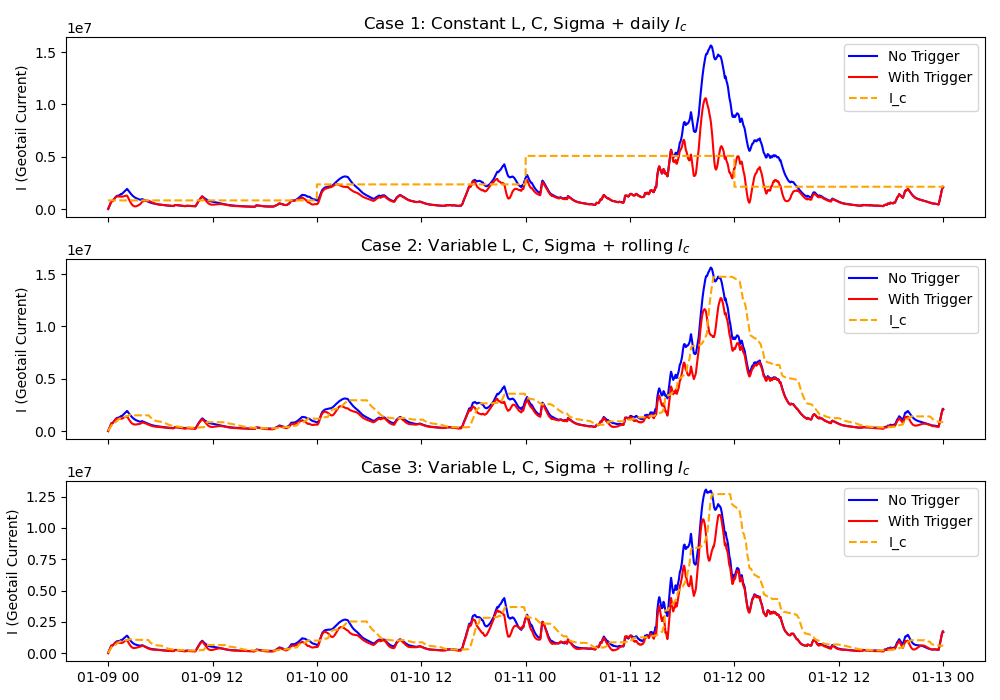

In [22]:
fig,ax = plt.subplots(3,1, figsize=(10,7), sharex=True)
plt.sca(ax[0])
plt.plot(out_no_trig_0.index, out_no_trig_0['I'], label='No Trigger',c='blue')
plt.plot(out_trig_0.index, out_trig_0['I'], label='With Trigger',c='red')
plt.plot(out_no_trig_0.index, Ic_0, label='I_c', color='orange',ls='--')
plt.ylabel('I (Geotail Current)')
plt.title("Case 1: Constant L, C, Sigma + daily $I_{c}$")
plt.legend()

plt.sca(ax[1])
plt.plot(out_no_trig_1.index, out_no_trig_1['I'], label='No Trigger',c='blue')
plt.plot(out_trig_1.index, out_trig_1['I'], label='With Trigger',c='red')
plt.plot(out_no_trig_1.index, Ic_1, label='I_c', color='orange',ls='--')
plt.ylabel('I (Geotail Current)')
plt.title("Case 2: Variable L, C, Sigma + rolling $I_{c}$")
plt.legend()

plt.sca(ax[2])
plt.plot(out_no_trig_2.index, out_no_trig_2['I'], label='No Trigger',c='blue')
plt.plot(out_trig_2.index, out_trig_2['I'], label='With Trigger',c='red')
plt.plot(out_no_trig_2.index, Ic_2, label='I_c', color='orange',ls='--')
plt.ylabel('I (Geotail Current)')
plt.title("Case 3: Variable L, C, Sigma + rolling $I_{c}$")
plt.legend()
plt.tight_layout()

C:\Users\soumy\AppData\Local\Temp\ipykernel_7552\3841521438.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


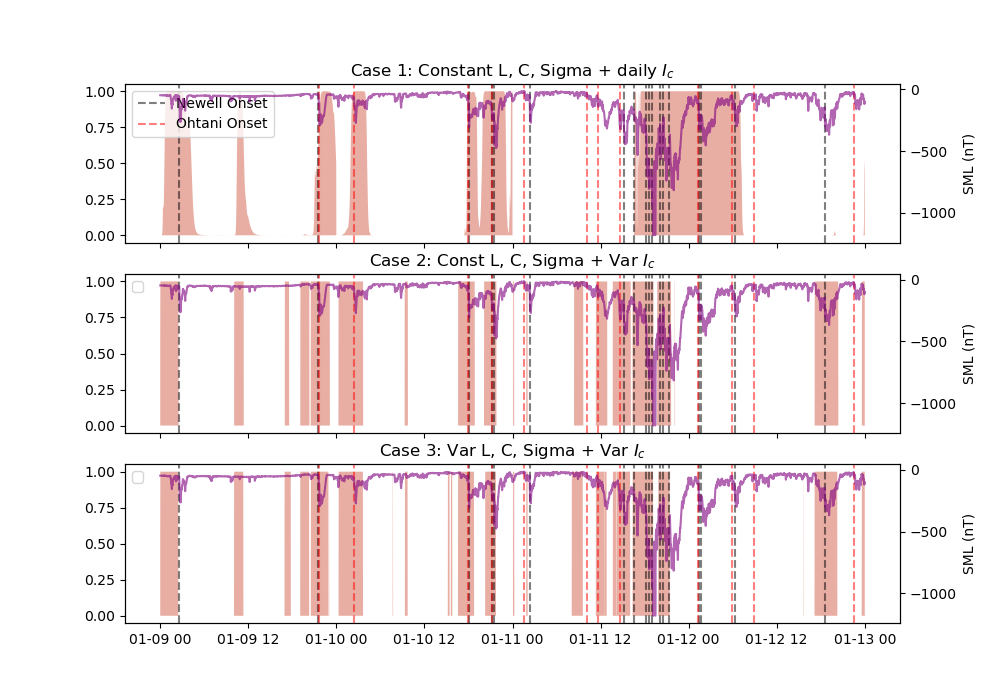

In [26]:
# make a similar figure for theta
fig,ax = plt.subplots(3,1, figsize=(10,7), sharex=True)
plt.sca(ax[0])
plt.fill_between(
    out_no_trig_0.index,
    0,
    theta_0,
    facecolor="#C7361C",
    alpha=0.4
)
plt.title("Case 1: Constant L, C, Sigma + daily $I_{c}$")

plt.sca(ax[1])
plt.fill_between(
    out_no_trig_1.index,
    0,
    theta_1,
    facecolor="#C7361C",
    alpha=0.4
)
plt.title("Case 2: Const L, C, Sigma + Var $I_{c}$")

plt.sca(ax[2])
plt.fill_between(
    out_no_trig_2.index,
    0,
    theta_2,
    facecolor="#C7361C",
    alpha=0.4
)
plt.title("Case 3: Var L, C, Sigma + Var $I_{c}$")

for ax0 in ax:
    plt.sca(ax0)
    for ss in Newell.loc[start:stop].index:
        plt.axvline(
            ss,
            color='k',
            alpha=0.5,
            linestyle='--',
            label='Newell Onset' if 'Newell Onset'
            not in ax[0].get_legend_handles_labels()[1] else ""
        )
    #same for Ohtani
    for ss in Ohtani.loc[start:stop].index:
        plt.axvline(
            ss,
            color='r',
            alpha=0.5,
            linestyle='--',
            label='Ohtani Onset' if 'Ohtani Onset'
            not in ax[0].get_legend_handles_labels()[1] else ""
        )
    plt.legend(loc='upper left')
    ax2 = plt.twinx()
    ax2.plot(SuperMag.SML.loc[start:stop], color='purple', alpha=0.6)
    ax2.set_ylabel('SML (nT)')
    



In [ ]:
## 

In [24]:
# plt.figure(figsize=(10,3))
# plt.plot(out_no_trig_0.index, out_no_trig_0['I'], label='No Trigger')
# plt.plot(out_trig_0.index, out_trig_0['I'], label='With Trigger')
# plt.plot(out_trig_0.index, out_trig_0['I_c'], label='Trigger Threshold')
# plt.legend()
# plt.ylabel('I (Current in A)')
# ax = plt.twinx()

# ax.fill_between(
#     out_trig_0.index,
#     0,
#     theta_0,
#     facecolor="#96CE25",
#     alpha=0.2,
#     edgecolor='none'
# )
# ax.set_ylabel('Theta (Trigger Function)')
# plt.tight_layout()

In [25]:
# fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# # -------------------- (1) Current + thresholds --------------------
# plt.sca(ax[0])

# plt.plot(out_no_trig_1.index, out_no_trig_1['I'], label='No Trigger')

# plt.plot(out_no_trig_1.index, Ic_0, label='Daily Trigger Threshold', color='orange')
# plt.plot(out_no_trig_1.index, Ic_1, label='Rolling Trigger Threshold', color='red')

# plt.ylabel('I (Geotail Current)')
# plt.title('WINDMI Output Current with Different Trigger Thresholds')
# plt.legend()


# # -------------------- (2) Theta + SML --------------------
# plt.sca(ax[1])

# plt.fill_between(
#     out_no_trig_1.index,
#     0,
#     theta_1,
#     facecolor="#C7361C",
#     alpha=0.4,
#     label='Rolling Theta'
# )

# ax2 = ax[1].twinx()
# ax2.plot(SuperMag.SML.loc[start:stop], color='purple', alpha=0.6)
# ax2.set_ylabel('SML (nT)')

# ax[1].legend(loc='upper left')


# # -------------------- (3) Model comparison --------------------
# plt.sca(ax[2])

# plt.plot(out_no_trig.index, out_no_trig['I'], label='No Trigger')
# plt.plot(out_trig.index, out_trig['I'], label='With Trigger')
# plt.plot(out_trig_rolling.index, out_trig_rolling['I'], 
#          label='Trigger with Rolling I_c')

# plt.ylabel('I (Geotail Current)')
# plt.legend()

# SS_onset = Newell.loc[start:stop]
# for t in SS_onset.index:
#     plt.axvline(
#         t,
#         color='k',
#         alpha=1,
#         linestyle='--',
#         label='Newell Onset' if 'Newell Onset'
#         not in ax2.get_legend_handles_labels()[1] else ""
#     )

# plt.tight_layout()